# Introduction to Linear Regression: Predicting Oil Volume
In this exercise, we will use historical production data from the Volve field to build a linear regression model.
Our goal is to predict the volume of oil produced (`BORE_OIL_VOL`) based on downhole pressure and choke size.

In [2]:
# Step 1: Import the Pandas package and Matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

# Ensure plots show up inline in the notebook
%matplotlib inline

## Loading and Understanding the Data
We start by importing the data into a dataframe called `df` and previewing it.

In [3]:
file_path = "Volve_Production_Data.csv"
df = pd.read_csv(file_path)

# Preview the first 5 rows
display(df.head())

,DATEPRD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
0,07-Apr-14,15/9-F-1 C,0.0,0.000,0.000,0.000,0.0,0.00000,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
1,08-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.00306,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
2,09-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.97901,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
3,10-Apr-14,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.54576,0.000,0.00,0.000,0.0,0.0,0.0,NaN,production
4,11-Apr-14,15/9-F-1 C,0.0,310.376,96.876,277.278,0.0,1.21599,33.098,10.48,33.072,0.0,0.0,0.0,NaN,production


Let's get a concise summary of the structure of the data and its statistics.

In [4]:
# Get structural summary
print(df.info())

# Get statistical summary (mean, min, max, standard deviation)
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   DATEPRD                   15634 non-null  object 
 1   NPD_WELL_BORE_NAME        15634 non-null  object 
 2   ON_STREAM_HRS             15349 non-null  float64
 3   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 4   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 5   AVG_DP_TUBING             8980 non-null   float64
 6   AVG_ANNULUS_PRESS         7890 non-null   float64
 7   AVG_CHOKE_SIZE_P          8919 non-null   float64
 8   AVG_WHP_P                 9155 non-null   float64
 9   AVG_WHT_P                 9146 non-null   float64
 10  DP_CHOKE_SIZE             15340 non-null  float64
 11  BORE_OIL_VOL              9161 non-null   float64
 12  BORE_GAS_VOL              9161 non-null   float64
 13  BORE_WAT_VOL              9161 non-null   float64
 14  BORE_W

,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL
count,15349.000000,8980.000000,8980.000000,8980.000000,7890.000000,8919.000000,9155.000000,9146.00000,15340.000000,9161.000000,9161.000000,9161.000000,5706.000000
mean,19.994172,181.803870,77.162970,154.028791,14.856100,55.168534,45.377815,67.72844,11.441063,1095.638031,161049.063094,1672.152931,5315.479145
std,8.369911,109.712365,45.657949,76.752381,8.406821,36.692924,24.752635,27.71903,19.816930,1323.541545,188136.409296,1706.980951,2181.487231
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-458.000000,0.000000
25%,24.000000,0.000000,0.000000,83.665000,10.841250,18.952990,31.148000,56.57775,0.000000,191.000000,29431.000000,20.000000,4338.250000
50%,24.000000,232.897000,103.186500,175.589000,16.308500,52.096880,37.934000,80.07150,2.385000,558.000000,87750.000000,1098.000000,5504.500000
75%,24.000000,255.401250,106.277000,204.320000,21.306500,99.924290,57.101500,88.06200,13.765250,1345.000000,202482.000000,3261.000000,6780.750000
max,25.000000,397.589000,108.502000,345.907000,30.020000,100.000000,137.311000,93.51000,125.719000,5902.000000,851132.000000,8020.000000,10014.000000


## Essential Data Cleaning
Unlike perfectly curated practice datasets, real industrial data has missing values.
A Linear Regression model cannot handle blank spaces (`NaN`), so we must clean the data first.
1. We will drop any rows where our target (Oil Volume) is completely missing.
2. We will fill any missing sensor readings with the average (mean) of that sensor.

In [5]:
# Drop rows where the target variable is missing
df = df.dropna(subset=['BORE_OIL_VOL'])

# Fill remaining missing values with the mean of their respective columns
df = df.fillna(df.mean(numeric_only=True))

print("Data cleaning complete. No missing values remain.")

Data cleaning complete. No missing values remain.


## Visualizing Linear Relationships
Linear regression models assume there is a relationship between the predictors and the response.
Let's see if this assumption holds true for our dataset using scatter plots.

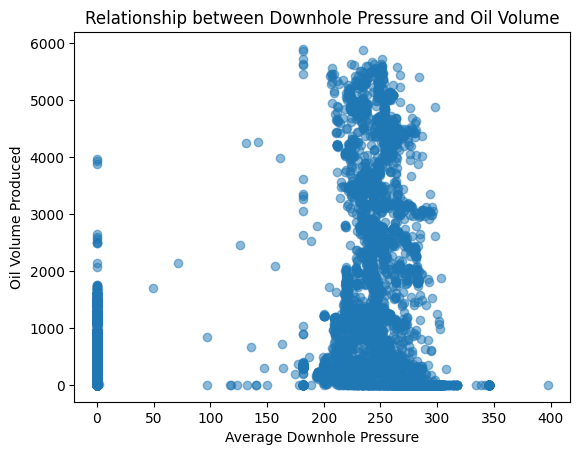

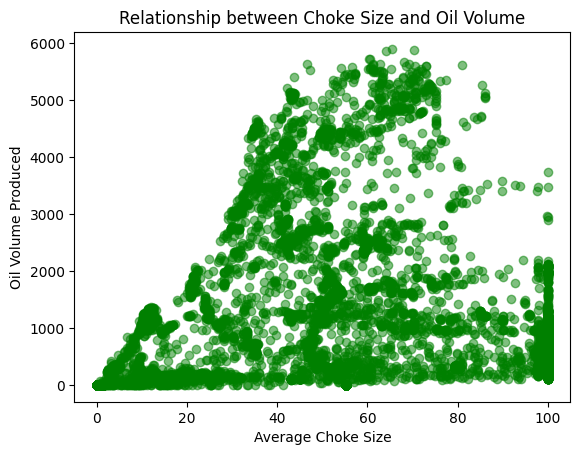

In [6]:
# Plot 1: Downhole Pressure vs Oil Volume
plt.scatter(df['AVG_DOWNHOLE_PRESSURE'], df['BORE_OIL_VOL'], alpha=0.5)
plt.title("Relationship between Downhole Pressure and Oil Volume")
plt.xlabel("Average Downhole Pressure")
plt.ylabel("Oil Volume Produced")
plt.show()

# Plot 2: Choke Size vs Oil Volume
plt.scatter(df['AVG_CHOKE_SIZE_P'], df['BORE_OIL_VOL'], alpha=0.5, color='green')
plt.title("Relationship between Choke Size and Oil Volume")
plt.xlabel("Average Choke Size")
plt.ylabel("Oil Volume Produced")
plt.show()

## Splitting the Data
Before we build our machine learning model, we need to split the data into training and test sets.
First, we separate the dependent variable (Y) from the independent variables (X).

In [7]:
# Separate the dependent variable (Target)
Y = df['BORE_OIL_VOL']

# Separate the independent variables (Features)
X = df[['AVG_DOWNHOLE_PRESSURE', 'AVG_CHOKE_SIZE_P']]

Next, we import the `train_test_split` function from the sklearn package and split our X and Y dataframes.
We will use 70% of the data to train the model, and 30% to test it.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 6412 rows
Testing data size: 2749 rows


## Building the Linear Regression Model
To build a linear regression model in Python, we import the `LinearRegression` class.
We then call the `fit` method and pass our training data to it.

In [9]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, Y_train)

LinearRegression()

## Interpreting the Model
The objective of linear regression is to estimate the intercept and slope values that best fit the data.
Let's look at the estimated intercept and the coefficients (slopes) for our features.

In [ ]:
# Get the intercept
print(f"Intercept: {model.intercept_:.2f}")

# Get the coefficients
print(f"Coefficient for Downhole Pressure: {model.coef_[0]:.2f}")
print(f"Coefficient for Choke Size: {model.coef_[1]:.2f}")

*Note on interpretation:* If the coefficient for choke size is positive, it means that as the choke size increases by 1 unit, the expected oil volume increases by that coefficient amount, assuming pressure stays exactly the same.

## Evaluating the Model
One way to evaluate a model is by calculating the coefficient of determination, or R-squared.
The closer this metric is to 1.0, the better the model explains the variance in the data.

In [ ]:
# Calculate R-squared using the test data
r_squared = model.score(X_test, Y_test)
print(f"R-squared Score: {r_squared:.4f}")

Another way to evaluate the model is to see how accurate it is on average.
We can do this by generating predictions and comparing them to the actual test values using Mean Absolute Error.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Get the model's predicted values for the test data
Y_pred = model.predict(X_test)

# Calculate the Mean Absolute Error
mae = mean_absolute_error(Y_test, Y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"This means our predictions are off by an average of +/- {mae:.2f} units of oil volume.")